# SE4050 Deep Learning 2026 - VGG16 Road-Damage Classification

Multi-label classification of road-damage patches into `D00`, `D10`, `D20`,
`D40` using an ImageNet-pretrained VGG16. Data lives under `dataset/`
(RDD-style, Czech + India XML labels, 4295 labeled images).

| Decision | Choice | Reason |
|---|---|---|
| Task | multi-label (sigmoid + BCE) | 1300/4295 images have more than one damage type |
| Data | Czech + India labels only | Japan labels lost upstream, test1/test2 have no annotations |
| Split | 70/15/15 grouped by near-duplicate | duplicates must not cross splits |
| Backbone | VGG16 + ImageNet weights, frozen | small data, CPU-only environment |
| Training | precomputed features + small head | trains in minutes on CPU |
| Test set | touched once, at the end | assignment rule |

Settings come from `.env` (see `.env.example`).

## 1. Setup

Configuration is read from `.env` (see `.env.example`); seeding, JSON and
timing helpers are defined right here so the notebook runs on its own.

In [4]:
import collections
import hashlib
import json
import os
import random
import sys
import time
from pathlib import Path
from xml.etree import ElementTree as ET

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from PIL import Image
from dotenv import load_dotenv
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score, precision_score,
                             recall_score, roc_auc_score, roc_curve)

In [5]:
PROJECT_ROOT = ROOT
load_dotenv(PROJECT_ROOT / ".env")

def _get(name, default):
    return os.environ.get(name, default)

class Config:
    data_dir: Path = PROJECT_ROOT / _get("DATA_DIR", "dataset")
    train_dir: Path = PROJECT_ROOT / _get("TRAIN_DIR", "dataset/train")
    results_dir: Path = PROJECT_ROOT / _get("RESULTS_DIR", "results")
    models_dir: Path = PROJECT_ROOT / _get("MODELS_DIR", "src/models")

    img_size: int = int(_get("IMG_SIZE", "224"))
    batch_size: int = int(_get("BATCH_SIZE", "64"))
    num_classes: int = int(_get("NUM_CLASSES", "4"))
    class_names: list = _get("CLASS_NAMES", "D00,D10,D20,D40").split(",")

    seed: int = int(_get("SEED", "42"))
    test_size: float = float(_get("TEST_SIZE", "0.15"))
    val_size: float = float(_get("VAL_SIZE", "0.15"))

    head_epochs: int = int(_get("HEAD_EPOCHS", "100"))
    head_lr: float = float(_get("HEAD_LR", "0.001"))
    dropout: float = float(_get("DROPOUT", "0.5"))
    patience_earlystop: int = int(_get("PATIENCE_EARLYSTOP", "12"))
    patience_lr: int = int(_get("PATIENCE_LR", "5"))

    checkpoint_path: Path = PROJECT_ROOT / _get(
        "CHECKPOINT_PATH", "src/models/vgg16_multilabel.keras")
    features_cache: Path = PROJECT_ROOT / _get(
        "FEATURES_CACHE", "results/cache/vgg16_features.npz")
    history_path: Path = PROJECT_ROOT / _get(
        "HISTORY_PATH", "results/metrics/training_history.json")

    @classmethod
    def ensure_dirs(cls):
        cls.models_dir.mkdir(parents=True, exist_ok=True)
        for sub in ("figures", "metrics", "cache", "predictions",
                    "error_analysis", "tables"):
            (cls.results_dir / sub).mkdir(parents=True, exist_ok=True)

    @classmethod
    def as_dict(cls):
        return {
            "data_dir": str(cls.data_dir),
            "img_size": cls.img_size,
            "batch_size": cls.batch_size,
            "num_classes": cls.num_classes,
            "class_names": cls.class_names,
            "seed": cls.seed,
            "test_size": cls.test_size,
            "val_size": cls.val_size,
            "head_epochs": cls.head_epochs,
            "head_lr": cls.head_lr,
            "dropout": cls.dropout,
            "patience_earlystop": cls.patience_earlystop,
            "patience_lr": cls.patience_lr,
            "checkpoint_path": str(cls.checkpoint_path),
            "features_cache": str(cls.features_cache),
            "models_dir": str(cls.models_dir),
        }

In [6]:
def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, default=_json_default)

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def _json_default(o):
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating,)):
        return float(o)
    if isinstance(o, np.ndarray):
        return o.tolist()
    if isinstance(o, Path):
        return str(o)
    raise TypeError(f"Object of type {type(o)} is not JSON serializable")

class Timer:
    def __enter__(self):
        self.start = time.perf_counter()
        return self
    def __exit__(self, *exc):
        self.elapsed = time.perf_counter() - self.start
        print(f"Elapsed: {self.elapsed:.1f} s")

def apply_style():
    plt.rcParams.update({
        "figure.dpi": 120, "savefig.dpi": 160, "axes.grid": True,
        "grid.alpha": 0.3, "figure.titlesize": 13, "axes.titlesize": 12,
        "axes.labelsize": 11,
    })

set_global_seed(Config.seed)
apply_style()
Config.ensure_dirs()

RUN = {}

print("TensorFlow :", tf.__version__)
print("NumPy      :", np.__version__)
print("seed       :", Config.seed)
print("classes    :", Config.class_names)
print("image size :", Config.img_size)
print("split      : test", Config.test_size, "val", Config.val_size)
print("GPU devices:", tf.config.list_physical_devices("GPU"))
print("\nConfiguration")
print(json.dumps(Config.as_dict(), indent=2))

TensorFlow : 2.21.0
NumPy      : 2.4.6
seed       : 42
classes    : ['D00', 'D10', 'D20', 'D40']
image size : 224
split      : test 0.15 val 0.15


GPU devices: []

Configuration
{
  "data_dir": "c:\\Users\\ASUS\\Desktop\\SLIIT\\Year 4\\Semester 2\\Deep Learning\\Assignment\\SE4050-Deep-Learning-Assignment\\dataset",
  "img_size": 224,
  "batch_size": 64,
  "num_classes": 4,
  "class_names": [
    "D00",
    "D10",
    "D20",
    "D40"
  ],
  "seed": 42,
  "test_size": 0.15,
  "val_size": 0.15,
  "head_epochs": 100,
  "head_lr": 0.001,
  "dropout": 0.5,
  "patience_earlystop": 12,
  "patience_lr": 5,
  "checkpoint_path": "c:\\Users\\ASUS\\Desktop\\SLIIT\\Year 4\\Semester 2\\Deep Learning\\Assignment\\SE4050-Deep-Learning-Assignment\\src\\models\\vgg16_multilabel.keras",
  "features_cache": "c:\\Users\\ASUS\\Desktop\\SLIIT\\Year 4\\Semester 2\\Deep Learning\\Assignment\\SE4050-Deep-Learning-Assignment\\results\\cache\\vgg16_features.npz",
  "models_dir": "c:\\Users\\ASUS\\Desktop\\SLIIT\\Year 4\\Semester 2\\Deep Learning\\Assignment\\SE4050-Deep-Learning-Assignment\\src\\models"
}


## 2. Dataset validation and EDA

Opens every image (corruption check), hashes all files (duplicate check),
parses the VOC annotations and writes stats to `results/metrics/`, figures to
`results/figures/`.

In [7]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}
stats_global = {}

def scan_images():
    '''One row per image across the train/test1/test2 folders.'''
    rows = []
    for split in ("train", "test1", "test2"):
        split_dir = Config.data_dir / split
        if not split_dir.is_dir():
            continue
        for class_dir in sorted(p for p in split_dir.iterdir() if p.is_dir()):
            images_dir = class_dir / "images"
            if not images_dir.is_dir():
                continue
            for img in sorted(images_dir.iterdir()):
                if img.suffix.lower() in IMAGE_EXTS:
                    rows.append({
                        "split": split,
                        "source": class_dir.name,
                        "path": img,
                        "bytes": img.stat().st_size,
                    })
    return pd.DataFrame(rows)

def check_images(df):
    '''Open every image; returns status, size and corrupt-file list.'''
    statuses, widths, heights, corrupt = [], [], [], []
    for p in df["path"]:
        try:
            with Image.open(p) as im:
                im.verify()
            with Image.open(p) as im:
                im.load()
                widths.append(im.width)
                heights.append(im.height)
            statuses.append("ok")
        except Exception as exc:
            statuses.append("corrupt")
            widths.append(np.nan)
            heights.append(np.nan)
            corrupt.append({"path": str(p), "error": f"{type(exc).__name__}: {exc}"})
    return statuses, widths, heights, corrupt

def exact_duplicates(df):
    '''Byte-identical images, grouped by content MD5.'''
    by_hash = collections.defaultdict(list)
    for p in df["path"]:
        h = hashlib.md5(p.read_bytes()).hexdigest()
        by_hash[h].append(str(p))
    return [v for v in by_hash.values() if len(v) > 1]

def parse_damage_labels():
    '''Multi-label table from the train/Czech + train/India VOC xml files.'''
    rows = []
    for country in ("Czech", "India"):
        xml_dir = Config.train_dir / country / "annotations" / "xmls"
        if not xml_dir.is_dir():
            continue
        for xml_path in sorted(xml_dir.glob("*.xml")):
            root = ET.parse(xml_path).getroot()
            objects = root.findall("object")
            classes = sorted(
                {o.findtext("name") for o in objects
                 if o.findtext("name") in Config.class_names}
            )
            img = xml_path.parents[2] / "images" / (xml_path.stem + ".jpg")
            if not img.exists():
                continue
            row = {"path": str(img), "source": country, "n_objects": len(objects)}
            for c in Config.class_names:
                row[c] = int(c in classes)
            row["labels"] = classes
            rows.append(row)
    return pd.DataFrame(rows)

def label_statistics(labels_df):
    stats = {
        "annotated_images": int(len(labels_df)),
        "images_with_no_object": int((labels_df["n_objects"] == 0).sum()),
        "images_with_main4_label": int(
            labels_df[Config.class_names].sum(axis=1).gt(0).sum()),
        "images_without_main4_label": int(
            labels_df[Config.class_names].sum(axis=1).eq(0).sum()),
        "per_class_image_counts": {
            c: int(labels_df[c].sum()) for c in Config.class_names
        },
        "multi_label_images": int(
            (labels_df[Config.class_names].sum(axis=1) > 1).sum()),
        "single_label_images": int(
            (labels_df[Config.class_names].sum(axis=1) == 1).sum()),
        "per_source": labels_df["source"].value_counts().to_dict(),
    }
    per_source_class = {}
    for src, grp in labels_df.groupby("source"):
        per_source_class[src] = {c: int(grp[c].sum()) for c in Config.class_names}
    stats["per_source_class_counts"] = per_source_class
    return stats

def make_figures(df, labels_df):
    fig_dir = Config.results_dir / "figures"

    counts = df.groupby(["split", "source"]).size().unstack(fill_value=0)
    ax = counts.plot(kind="bar", figsize=(8, 4), rot=0, colormap="tab10")
    ax.set_title("Images per split and source country")
    ax.set_ylabel("number of images")
    ax.legend(title="source")
    plt.tight_layout()
    plt.savefig(fig_dir / "class_distribution_splits.png")
    plt.close()

    per_class = labels_df[Config.class_names].sum()
    ax = per_class.plot(kind="bar", figsize=(7, 4), rot=0, color="#4c72b0")
    ax.set_title("Annotated images per damage class (train/Czech+India)")
    ax.set_ylabel("images containing class")
    for i, v in enumerate(per_class):
        ax.text(i, v, str(int(v)), ha="center", va="bottom")
    plt.tight_layout()
    plt.savefig(fig_dir / "damage_class_distribution.png")
    plt.close()

    n_labels = labels_df[Config.class_names].sum(axis=1)
    ax = n_labels.value_counts().sort_index().plot(kind="bar", figsize=(6, 4), rot=0)
    ax.set_title("Number of damage classes per annotated image")
    ax.set_xlabel("labels per image")
    ax.set_ylabel("images")
    plt.tight_layout()
    plt.savefig(fig_dir / "labels_per_image.png")
    plt.close()

    src_cls = pd.DataFrame(stats_global["per_source_class_counts"]).T
    ax = src_cls.plot(kind="bar", figsize=(7, 4), rot=0, colormap="Set2")
    ax.set_title("Class distribution by source country")
    ax.set_ylabel("images containing class")
    plt.tight_layout()
    plt.savefig(fig_dir / "class_distribution_by_source.png")
    plt.close()

def validate_dataset():
    print("Scanning dataset ...")
    df = scan_images()
    print(f"found {len(df)} images")

    print("Checking image integrity (this reads every file) ...")
    statuses, widths, heights, corrupt = check_images(df)
    df["status"] = statuses
    df["width"] = widths
    df["height"] = heights
    ok = df[df["status"] == "ok"]
    print(f"ok={len(ok)} corrupt={len(corrupt)}")

    dup_groups = exact_duplicates(df)
    print(f"exact duplicate groups: {len(dup_groups)}")

    print("Parsing damage labels ...")
    labels_df = parse_damage_labels()
    label_stats = label_statistics(labels_df)
    stats_global.update(label_stats)

    stats = {
        "total_images": int(len(df)),
        "per_split": df["split"].value_counts().to_dict(),
        "per_split_source": (
            df.groupby(["split", "source"]).size().unstack(fill_value=0).to_dict()),
        "image_sizes": {
            f"{w}x{h}": int(n)
            for (w, h), n in df.groupby(["width", "height"]).size().items()
        },
        "corrupt_images": corrupt,
        "exact_duplicate_groups": dup_groups,
        "labels": label_stats,
        "notes": [
            "Damage labels are only available for train/Czech and train/India "
            "(VOC xml annotations). The upstream train.tar.gz download was "
            "truncated and the Japan labels were never recovered, so the "
            "unused Japan images were removed from the local dataset; "
            "test1/test2 ship without damage annotations.",
            "test1/test2 still carry source-country folder names and are used "
            "only for dataset description, not for damage evaluation.",
        ],
    }

    make_figures(df, labels_df)

    save_json(stats, Config.results_dir / "metrics" / "dataset_stats.json")
    df.drop(columns="path").assign(
        path=[str(p) for p in df["path"]]
    ).to_csv(Config.results_dir / "metrics" / "image_inventory.csv", index=False)
    labels_df.drop(columns="path").assign(
        path=[str(p) for p in labels_df["path"]]
    ).to_csv(Config.results_dir / "metrics" / "label_table.csv", index=False)
    print("Saved dataset stats + figures to", Config.results_dir)
    return stats

In [8]:
stats = validate_dataset()
RUN["dataset"] = {
    "total_images": stats["total_images"],
    "per_split": stats["per_split"],
    "corrupt": len(stats["corrupt_images"]),
    "exact_duplicate_groups": len(stats["exact_duplicate_groups"]),
}

Scanning dataset ...
found 15830 images
Checking image integrity (this reads every file) ...
ok=15830 corrupt=0
exact duplicate groups: 0
Parsing damage labels ...
Saved dataset stats + figures to c:\Users\ASUS\Desktop\SLIIT\Year 4\Semester 2\Deep Learning\Assignment\SE4050-Deep-Learning-Assignment\results


In [9]:
print("images per split:", stats["per_split"])
print("image sizes     :", stats["image_sizes"])
print("corrupt images  :", stats["corrupt_images"])
print("duplicate groups:", len(stats["exact_duplicate_groups"]))
print()
print("Damage-label table (train/Czech + train/India):")
for k, v in stats["labels"].items():
    print(f"  {k}: {v}")

images per split: {'train': 10535, 'test2': 2664, 'test1': 2631}
image sizes     : {'540x540': 28, '600x600': 6081, '720x720': 9665, '1024x1024': 44, '1080x1080': 12}
corrupt images  : []
duplicate groups: 0

Damage-label table (train/Czech + train/India):
  annotated_images: 10535
  images_with_no_object: 5678
  images_with_main4_label: 4295
  images_without_main4_label: 6240
  per_class_image_counts: {'D00': 1873, 'D10': 360, 'D20': 1887, 'D40': 1684}
  multi_label_images: 1300
  single_label_images: 2995
  per_source: {'India': 7706, 'Czech': 2829}
  per_source_class_counts: {'Czech': {'D00': 764, 'D10': 300, 'D20': 129, 'D40': 154}, 'India': {'D00': 1109, 'D10': 60, 'D20': 1758, 'D40': 1530}}


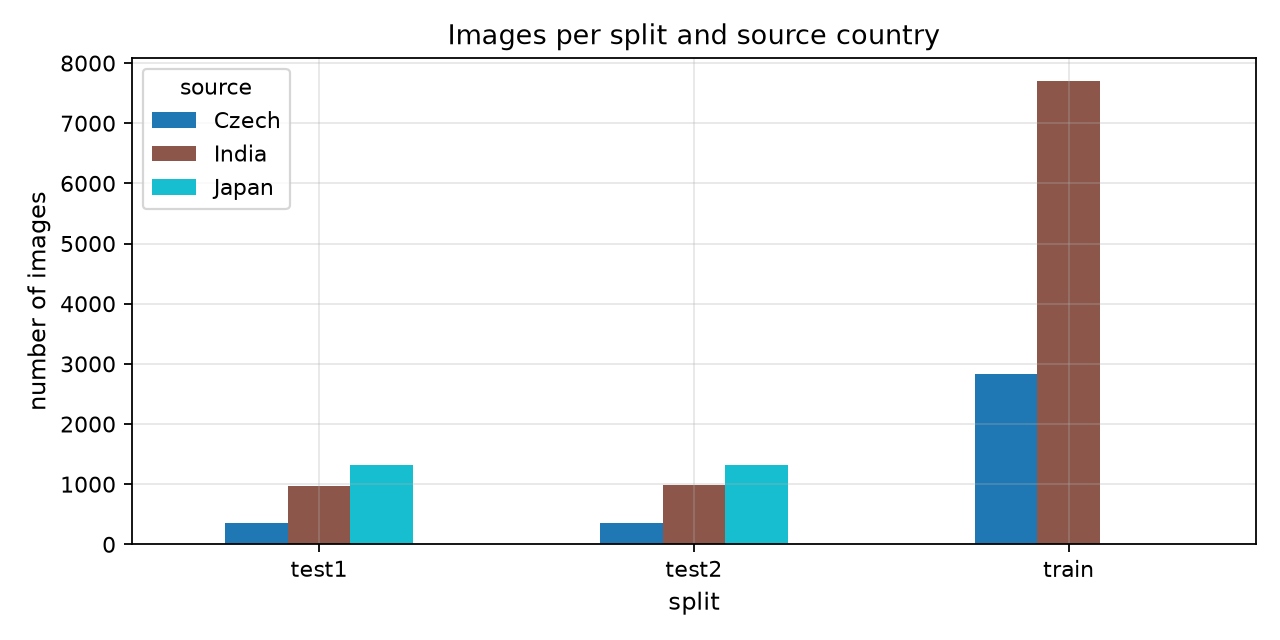

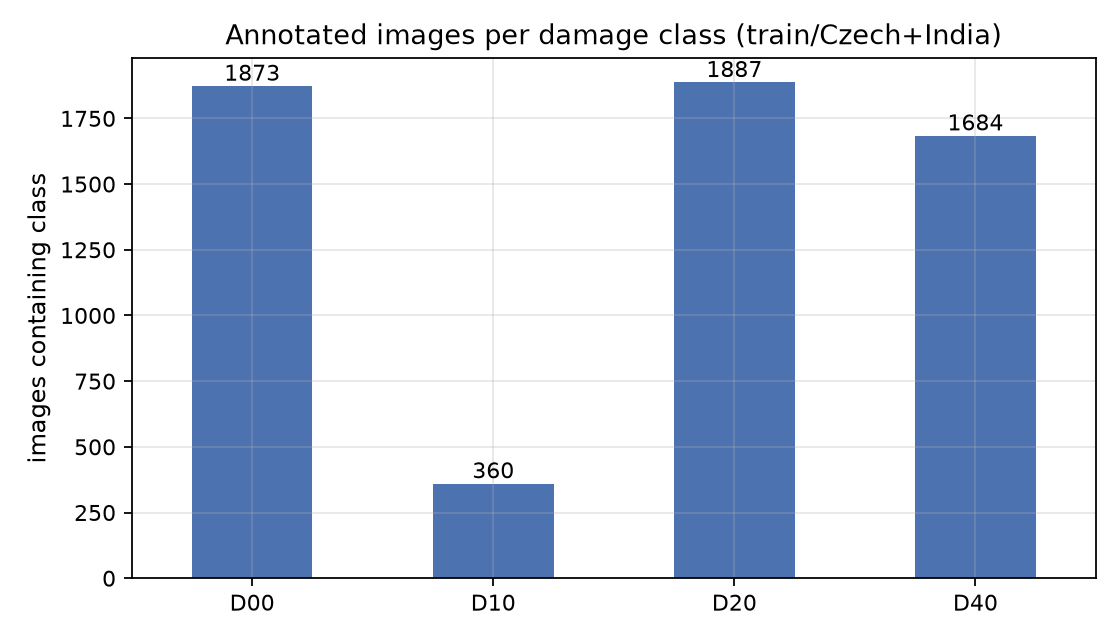

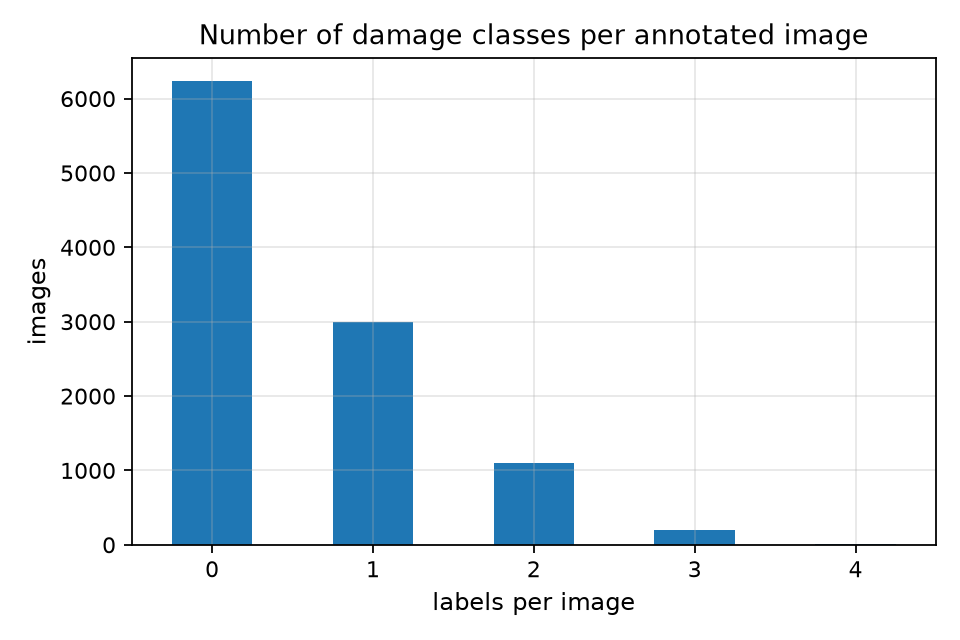

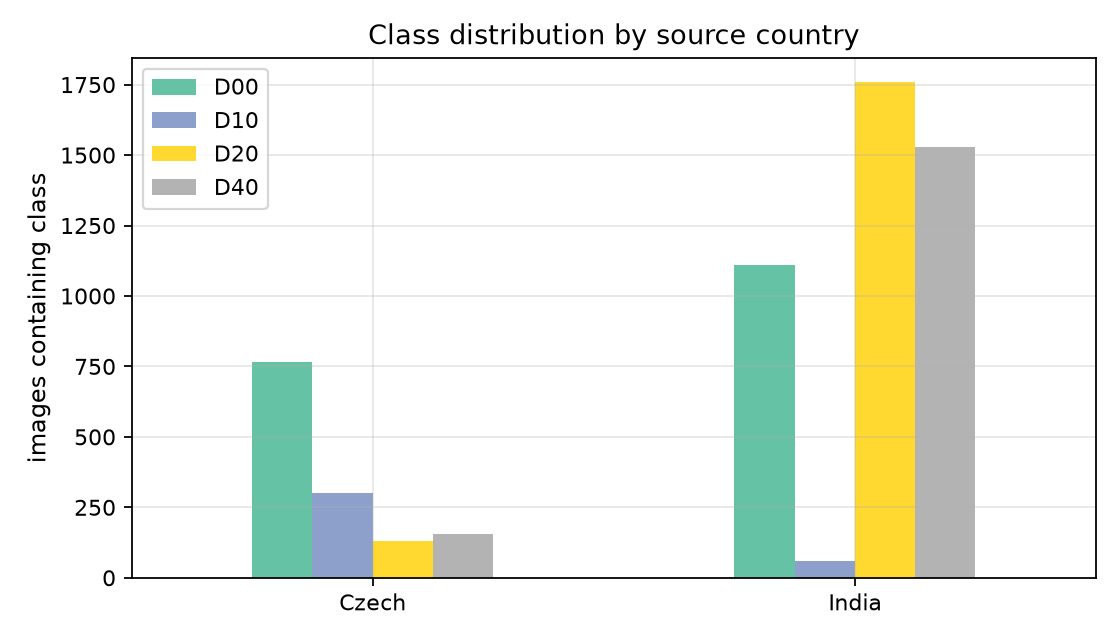

In [10]:
from IPython.display import Image as IPyImage, display

for fig in ("class_distribution_splits.png",
            "damage_class_distribution.png",
            "labels_per_image.png",
            "class_distribution_by_source.png"):
    display(IPyImage(filename=str(Config.results_dir / "figures" / fig)))

## 3. Labels and leakage-safe split

* keep images with at least one of the four classes (4295 images);
* cluster near-duplicates with a 64-bit dHash (Hamming <= 4);
* assign whole clusters to train/val/test 70/15/15, so duplicates never
  cross a split;
* `results/metrics/split_manifest.csv` is shared by all group models.

In [11]:
MANIFEST_PATH = Config.results_dir / "metrics" / "split_manifest.csv"
NEAR_DUP_MAX_HAMMING = 4   # 64-bit dHash: <=4 means visually near-identical

def build_label_table():
    '''Images that carry at least one of the four damage labels.'''
    df = parse_damage_labels()
    n_main = df[Config.class_names].sum(axis=1)
    df = df[n_main > 0].reset_index(drop=True)
    df["primary"] = df[Config.class_names].idxmax(axis=1)
    return df

def dhash(path, size=8):
    '''64-bit difference hash (resize + grey, compare neighbours).'''
    with Image.open(path) as im:
        g = im.convert("L").resize((size + 1, size), Image.LANCZOS)
        pixels = np.asarray(g)
    bits = 0
    for row in range(size):
        for col in range(size):
            bits = (bits << 1) | (1 if pixels[row, col] > pixels[row, col + 1] else 0)
    return bits

def _hamming_matrix(hashes, chunk=256):
    '''Pairwise Hamming distances of 64-bit hashes, chunked to save memory.'''
    b = np.unpackbits(hashes.view(np.uint8).reshape(hashes.size, 8), axis=1)
    n = b.shape[0]
    dist = np.empty((n, n), dtype=np.int16)
    for start in range(0, n, chunk):
        end = min(start + chunk, n)
        diff = b[start:end, None, :] != b[None, :, :]
        dist[start:end] = diff.sum(axis=2)
    return dist

def find_near_duplicate_clusters(paths, max_hamming=NEAR_DUP_MAX_HAMMING):
    '''Union-Find over perceptually near-identical images.'''
    hashes = np.array([dhash(p) for p in paths], dtype=np.uint64)
    dist = _hamming_matrix(hashes)
    n = len(paths)
    parent = list(range(n))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    iu = np.triu_indices(n, k=1)
    close = np.where(dist[iu] <= max_hamming)[0]
    for idx in close:
        union(int(iu[0][idx]), int(iu[1][idx]))

    groups = collections.defaultdict(list)
    for i in range(n):
        groups[find(i)].append(i)
    clusters = sorted((sorted(v) for v in groups.values()), key=lambda c: -len(c))
    return clusters, hashes

def _greedy_cluster_split(df, clusters):
    '''Assign whole clusters to train/val/test, hitting per-class targets.'''
    rng = np.random.default_rng(Config.seed)
    n = len(df)
    primaries = df["primary"].to_numpy()
    split = np.full(n, "", dtype=object)
    used = collections.Counter()

    cluster_primary = []
    for cl in clusters:
        votes = collections.Counter(primaries[cl])
        cluster_primary.append(votes.most_common(1)[0][0])

    order = np.arange(len(clusters))
    rng.shuffle(order)

    class_totals = collections.Counter(primaries)
    progress = collections.defaultdict(lambda: {"test": 0.0, "val": 0.0})

    for ci in order:
        cl = clusters[ci]
        label = cluster_primary[ci]
        size = len(cl)
        deficit = {}
        for sp, target in (("test", Config.test_size), ("val", Config.val_size)):
            want = class_totals[label] * target
            deficit[sp] = want - progress[label][sp]
        if deficit["test"] >= deficit["val"] and deficit["test"] > 0:
            choice = "test"
        elif deficit["val"] > 0:
            choice = "val"
        else:
            choice = "train"
        for i in cl:
            split[i] = choice
        progress[label][choice] = progress[label].get(choice, 0.0) + size
        used[choice] += size

    for sp in ("train", "val", "test"):
        if used[sp] == 0:
            raise RuntimeError(f"empty split: {sp}")
    return pd.Series(split, index=df.index, name="split")

def create_or_load_split(force=False):
    '''Label table + split column; a saved manifest is reused.'''
    df = build_label_table()
    if MANIFEST_PATH.exists() and not force:
        manifest = pd.read_csv(MANIFEST_PATH)
        if list(manifest["path"]) == list(df["path"]):
            df["split"] = manifest["split"]
            df["cluster_id"] = manifest["cluster_id"]
            print(f"Loaded existing split manifest: {MANIFEST_PATH}")
            return df
        print("Manifest does not match current data - rebuilding split.")

    print("Computing perceptual hashes / near-duplicate clusters ...")
    clusters, hashes = find_near_duplicate_clusters(list(df["path"]))
    multi = [c for c in clusters if len(c) > 1]
    print(f"{len(df)} images -> {len(clusters)} clusters "
          f"({len(multi)} with duplicates)")

    print("Assigning leakage-safe splits ...")
    df["split"] = _greedy_cluster_split(df, clusters)

    df["dhash"] = [format(int(h), "016x") for h in hashes]
    df["cluster_id"] = -1
    for cid, cl in enumerate(clusters):
        df.loc[df.index[cl], "cluster_id"] = cid
    df.drop(columns="dhash").to_csv(MANIFEST_PATH, index=False)

    report = {
        "n_images": int(len(df)),
        "n_clusters": int(len(clusters)),
        "n_clusters_with_duplicates": int(len(multi)),
        "largest_cluster": int(max(len(c) for c in clusters)),
        "split_counts": df["split"].value_counts().to_dict(),
        "per_class_split": (
            df.groupby("split")[Config.class_names].sum().astype(int).to_dict()
        ),
        "per_source_split": pd.crosstab(df["split"], df["source"]).to_dict(),
    }
    save_json(report, Config.results_dir / "metrics" / "split_report.json")
    print("Saved split manifest ->", MANIFEST_PATH)
    return df

def load_xy(df, split):
    '''Paths and binary label matrix for one split.'''
    part = df[df["split"] == split]
    y = part[Config.class_names].to_numpy(dtype=np.float32)
    return list(part["path"]), y

def leakage_report(df):
    '''Checks that no cluster and no path crosses split boundaries.'''
    cluster_splits = df.groupby("cluster_id")["split"].nunique()
    cross = cluster_splits[cluster_splits > 1]
    dup_paths = df["path"].duplicated().sum()
    return {
        "clusters_spanning_multiple_splits": int(len(cross)),
        "duplicate_paths": int(dup_paths),
        "split_counts": df["split"].value_counts().to_dict(),
        "passed": bool(len(cross) == 0 and dup_paths == 0),
    }

In [12]:
with Timer():
    labels_df = create_or_load_split(force=True)

leak = leakage_report(labels_df)
print("leakage report:", leak)
RUN["leakage"] = leak
assert leak["passed"], "split leakage detected"

print("\nimages per split:")
print(labels_df["split"].value_counts())
print("\nlabel counts per split (multi-label):")
print(labels_df.groupby("split")[Config.class_names].sum())
print("\nsource per split:")
print(pd.crosstab(labels_df["split"], labels_df["source"]))

Computing perceptual hashes / near-duplicate clusters ...
4295 images -> 4095 clusters (82 with duplicates)
Assigning leakage-safe splits ...
Saved split manifest -> c:\Users\ASUS\Desktop\SLIIT\Year 4\Semester 2\Deep Learning\Assignment\SE4050-Deep-Learning-Assignment\results\metrics\split_manifest.csv
Elapsed: 29.9 s
leakage report: {'clusters_spanning_multiple_splits': 0, 'duplicate_paths': 0, 'split_counts': {'train': 3005, 'val': 645, 'test': 645}, 'passed': True}

images per split:
split
train    3005
val       645
test      645
Name: count, dtype: int64

label counts per split (multi-label):
        D00  D10   D20   D40
split                       
test    275   51   290   265
train  1312  259  1320  1165
val     286   50   277   254

source per split:
source  Czech  India
split               
test      137    508
train     772   2233
val       163    482


In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
split_cls = labels_df.groupby("split")[Config.class_names].sum().loc[["train", "val", "test"]]
split_cls.plot(kind="bar", ax=ax, rot=0, colormap="tab10")
ax.set_title("Label distribution across train / val / test")
ax.set_ylabel("images containing class")
plt.tight_layout()
plt.savefig(Config.results_dir / "figures" / "split_label_distribution.png")
plt.close()

## 4. Preprocessing

| Step | Why |
|---|---|
| resize to 224 x 224 | VGG16 input size (source patches are 600/720/1024 px) |
| `vgg16.preprocess_input` | normalization used by the ImageNet weights |
| no augmentation | backbone is frozen, features are precomputed once |
| thresholds tuned on validation only | test stays unseen |

Data checks from section 2: 0 corrupt, 0 exact duplicates, 82 near-duplicate
clusters (kept inside one split). The upstream `train.tar.gz` is truncated -
reported, not patched.

## 5. Model architecture

**Backbone:** `VGG16(include_top=False, pooling='avg')` with ImageNet weights,
~14.7M parameters, entirely frozen, outputs a 512-d feature vector per image.

**Head** (the trainable part, ~132k parameters):

| Layer | Units | Activation |
|---|---|---|
| Input | 512 | - |
| Dense | 256 | ReLU |
| Dropout (0.5) | - | - |
| Dense | 4 | Sigmoid |

Training: binary cross-entropy, Adam 1e-3 (halved on plateau), batch 64,
early stopping on validation AUC.

In [14]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

backbone = VGG16(
    include_top=False,
    weights="imagenet",
    pooling="avg",
    input_shape=(Config.img_size, Config.img_size, 3),
)
backbone.trainable = False

head = models.Sequential(
    [
        layers.Input(shape=(512,), name="vgg16_features"),
        layers.Dense(256, activation="relu", name="fc1"),
        layers.Dropout(Config.dropout, name="dropout"),
        layers.Dense(Config.num_classes, activation="sigmoid", name="damage"),
    ],
    name="classification_head",
)

inp = layers.Input(shape=(Config.img_size, Config.img_size, 3), name="image")
out = head(backbone(inp))
model = models.Model(inp, out, name="VGG16_multilabel")

for m in (model, head):
    m.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=Config.head_lr),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="binary_acc"),
            tf.keras.metrics.AUC(name="auc", multi_label=True),
        ],
    )

total_params = model.count_params()
trainable = int(np.sum([np.prod(w.shape) for w in model.trainable_weights]))
frozen = total_params - trainable
RUN["model"] = {
    "total_params": total_params,
    "trainable_params": trainable,
    "frozen_params": frozen,
}
print(f"total params     : {total_params:,}")
print(f"trainable params : {trainable:,}")
print(f"frozen params    : {frozen:,}")
model.summary()

HEAD_WEIGHTS = Config.checkpoint_path.with_name("vgg16_head.weights.h5")
FULL_MODEL = Config.checkpoint_path

total params     : 14,847,044
trainable params : 132,356
frozen params    : 14,714,688


Model: "VGG16_multilabel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 512)            │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_head             │ (None, 4)              │       132,356 │
│ (Sequential)                    │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,044 (56.64 MB)

 Trainable params: 132,356 (517.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## 6. Feature extraction

One forward pass per image, cached in `results/cache/vgg16_features*.npz`. The
cache is reused only if the image list, image size and backbone are unchanged.

In [15]:
from tensorflow.keras.applications.vgg16 import preprocess_input

def load_batch(paths, size):
    '''Read images, resize, apply VGG16 normalization.'''
    batch = np.empty((len(paths), size, size, 3), dtype=np.float32)
    for i, p in enumerate(paths):
        with open(p, "rb") as f:
            data = f.read()
        img = tf.io.decode_image(data, channels=3, expand_animations=False)
        img = tf.image.resize(img, (size, size), method="bilinear")
        batch[i] = img.numpy()
    return preprocess_input(batch)


EXTRACT_LOG = {}


def extract_features(paths, backbone, size, cache_path):
    '''Return (N, 512) features, cached on disk.'''
    key = hashlib_md5("\n".join(paths) + f"|{size}|vgg16")
    if cache_path.exists():
        cached = np.load(cache_path, allow_pickle=False)
        if str(cached["key"]) == key and len(cached["features"]) == len(paths):
            elapsed = float(cached["elapsed"]) if "elapsed" in cached.files else 0.0
            EXTRACT_LOG[cache_path.name] = elapsed
            print(f"feature cache hit: {cache_path.name} "
                  f"(original extraction {elapsed:.0f}s)")
            return cached["features"].astype(np.float32)
        print("feature cache stale -> re-extracting")
    feats = []
    t0 = time.time()
    bs = Config.batch_size
    for start in range(0, len(paths), bs):
        chunk = paths[start : start + bs]
        feats.append(backbone.predict(load_batch(chunk, size), verbose=0))
        done = start + len(chunk)
        if done % (bs * 10) == 0 or done == len(paths):
            print(f"  {done}/{len(paths)} images  ({time.time()-t0:.0f}s)", end="\r")
    feats = np.vstack(feats).astype(np.float32)
    elapsed = time.time() - t0
    EXTRACT_LOG[cache_path.name] = elapsed
    np.savez_compressed(cache_path, key=np.str_(key), features=feats,
                        elapsed=np.float64(elapsed))
    print(f"\nextracted {feats.shape} in {elapsed:.0f}s -> {cache_path.name}")
    return feats


def hashlib_md5(text):
    import hashlib
    return hashlib.md5(text.encode("utf-8")).hexdigest()

In [16]:
train_paths, y_train = load_xy(labels_df, "train")
val_paths, y_val = load_xy(labels_df, "val")
test_paths, y_test = load_xy(labels_df, "test")
print(len(train_paths), len(val_paths), len(test_paths))

X_train = extract_features(train_paths, backbone, Config.img_size, Config.features_cache)
X_val = extract_features(val_paths, backbone, Config.img_size, Config.features_cache.with_name(Config.features_cache.stem + "_val.npz"))
X_test = extract_features(test_paths, backbone, Config.img_size, Config.features_cache.with_name(Config.features_cache.stem + "_test.npz"))

RUN["feature_seconds"] = round(sum(EXTRACT_LOG.values()), 1)
print("feature extraction (sum over splits):", RUN["feature_seconds"], "s")
for name, secs in EXTRACT_LOG.items():
    print(f"  {name}: {secs:.1f}s")
print("features:", X_train.shape, X_val.shape, X_test.shape)

3005 645 645
feature cache stale -> re-extracting
  3005/3005 images  (218s)
extracted (3005, 512) in 218s -> vgg16_features.npz
feature cache stale -> re-extracting
  645/645 images  (47s)
extracted (645, 512) in 47s -> vgg16_features_val.npz
feature cache stale -> re-extracting
  645/645 images  (49s)
extracted (645, 512) in 49s -> vgg16_features_test.npz
feature extraction (sum over splits): 313.8 s
  vgg16_features.npz: 217.7s
  vgg16_features_val.npz: 47.5s
  vgg16_features_test.npz: 48.6s
features: (3005, 512) (645, 512) (645, 512)


## 7. Training the head

* `binary_crossentropy`, Adam 1e-3, metrics: binary accuracy + multi-label AUC
* `EarlyStopping(patience=12)`, `ReduceLROnPlateau(patience=5)`,
  best-weights checkpoint
* seed 42 for Python / NumPy / TensorFlow
* a re-run skips training when the checkpoint and `run_meta.json` match.

In [17]:
run_meta = {
    "config": Config.as_dict(),
    "split_md5": hashlib_md5("\n".join(train_paths + val_paths + test_paths)),
    "feature_key": hashlib_md5(str(Config.img_size) + "vgg16"),
}
meta_path = Config.checkpoint_path.with_name("run_meta.json")

train_skipped = False
if (FULL_MODEL.exists() and HEAD_WEIGHTS.exists() and meta_path.exists()
        and Config.history_path.exists()):
    previous = load_json(meta_path)
    if previous == run_meta:
        train_skipped = True
        print("Valid checkpoint + matching config found -> skipping training.")

history = None
if not train_skipped:
    class BestHeadWeights(tf.keras.callbacks.Callback):
        '''Saves head weights when val_auc improves.'''
        def __init__(self, path, monitor="val_auc"):
            super().__init__()
            self.path = str(path)
            self.monitor = monitor
            self.best = -np.inf
        def on_epoch_end(self, epoch, logs=None):
            value = (logs or {}).get(self.monitor)
            if value is not None and value > self.best:
                self.best = float(value)
                self.model.save_weights(self.path)

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_auc", mode="max",
            patience=Config.patience_earlystop, restore_best_weights=True,
            verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_auc", mode="max",
            factor=0.5, patience=Config.patience_lr, min_lr=1e-6, verbose=1),
        BestHeadWeights(HEAD_WEIGHTS, monitor="val_auc"),
    ]

    with Timer() as train_timer:
        history = head.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=Config.head_epochs,
            batch_size=Config.batch_size,
            shuffle=True,
            callbacks=callbacks,
            verbose=2,
        )
    RUN["train_seconds"] = round(train_timer.elapsed, 1)
    hist = {k: [float(v) for v in vals] for k, vals in history.history.items()}
    save_json(hist, Config.history_path)
    save_json(run_meta, meta_path)
    model.save(str(FULL_MODEL))
    print(f"trained in {RUN['train_seconds']}s, "
          f"best val AUC {max(hist['val_auc']):.4f}")
else:
    hist = load_json(Config.history_path)
    RUN["train_seconds"] = None
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")   # saved optimizer state != fresh head
        head.load_weights(str(HEAD_WEIGHTS))
    print("loaded history:", {k: round(v[-1], 4) for k, v in hist.items()})

Epoch 1/100
47/47 - 3s - 54ms/step - auc: 0.6222 - binary_acc: 0.6694 - loss: 0.8675 - val_auc: 0.7373 - val_binary_acc: 0.7442 - val_loss: 0.5079 - learning_rate: 0.0010
Epoch 2/100
47/47 - 1s - 11ms/step - auc: 0.7399 - binary_acc: 0.7375 - loss: 0.5164 - val_auc: 0.7728 - val_binary_acc: 0.7605 - val_loss: 0.4844 - learning_rate: 0.0010
Epoch 3/100
47/47 - 0s - 9ms/step - auc: 0.7838 - binary_acc: 0.7592 - loss: 0.4834 - val_auc: 0.7868 - val_binary_acc: 0.7655 - val_loss: 0.4743 - learning_rate: 0.0010
Epoch 4/100
47/47 - 1s - 11ms/step - auc: 0.8036 - binary_acc: 0.7740 - loss: 0.4654 - val_auc: 0.7955 - val_binary_acc: 0.7655 - val_loss: 0.4680 - learning_rate: 0.0010
Epoch 5/100
47/47 - 0s - 9ms/step - auc: 0.8272 - binary_acc: 0.7864 - loss: 0.4413 - val_auc: 0.8100 - val_binary_acc: 0.7717 - val_loss: 0.4547 - learning_rate: 0.0010
Epoch 6/100
47/47 - 0s - 8ms/step - auc: 0.8372 - binary_acc: 0.7928 - loss: 0.4293 - val_auc: 0.8106 - val_binary_acc: 0.7775 - val_loss: 0.4539 -

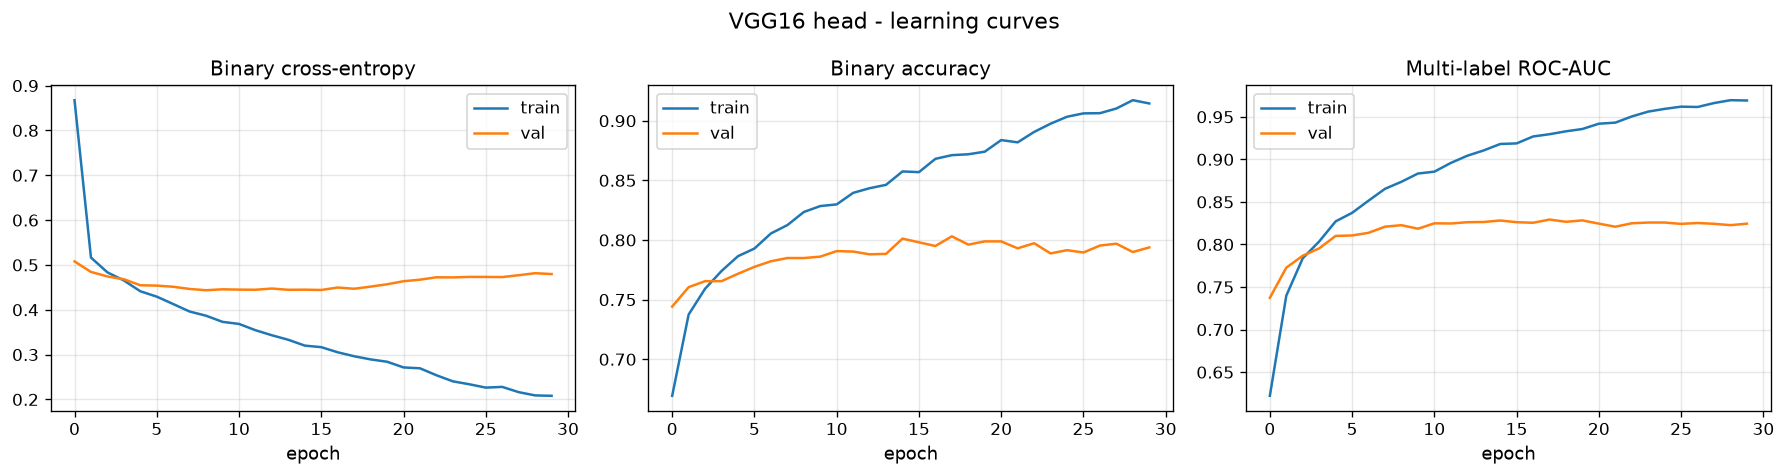

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(hist["loss"], label="train")
axes[0].plot(hist["val_loss"], label="val")
axes[0].set_title("Binary cross-entropy")
axes[1].plot(hist["binary_acc"], label="train")
axes[1].plot(hist["val_binary_acc"], label="val")
axes[1].set_title("Binary accuracy")
axes[2].plot(hist["auc"], label="train")
axes[2].plot(hist["val_auc"], label="val")
axes[2].set_title("Multi-label ROC-AUC")
for ax in axes:
    ax.set_xlabel("epoch")
    ax.legend()
    ax.grid(alpha=0.3)
plt.suptitle("VGG16 head - learning curves")
plt.tight_layout()
plt.savefig(Config.results_dir / "figures" / "learning_curves.png")
plt.show()

## 8. Evaluation on the test set (threshold 0.5)

The test set is used only here. Metrics: subset accuracy, per-class
precision / recall / F1 / ROC-AUC, micro and macro averages.

In [19]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")   # saved optimizer state != fresh head
    head.load_weights(str(HEAD_WEIGHTS))
print("loaded best head weights:", HEAD_WEIGHTS.name)

prob_val = head.predict(X_val, verbose=0)
prob_test = head.predict(X_test, verbose=0)
pred_val = (prob_val >= 0.5).astype(int)
pred_test = (prob_test >= 0.5).astype(int)

def multilabel_metrics(y_true, pred, prob, average):
    return {
        "precision": precision_score(y_true, pred, average=average, zero_division=0),
        "recall": recall_score(y_true, pred, average=average, zero_division=0),
        "f1": f1_score(y_true, pred, average=average, zero_division=0),
        "roc_auc": roc_auc_score(y_true, prob, average=average),
    }

metrics = {
    "threshold": 0.5,
    "subset_accuracy": float(accuracy_score(y_test, pred_test)),
    "hamming_accuracy": float((y_test == pred_test).mean()),
    "micro": multilabel_metrics(y_test, pred_test, prob_test, "micro"),
    "macro": multilabel_metrics(y_test, pred_test, prob_test, "macro"),
    "per_class": {},
}
for i, c in enumerate(Config.class_names):
    metrics["per_class"][c] = {
        "precision": float(precision_score(y_test[:, i], pred_test[:, i], zero_division=0)),
        "recall": float(recall_score(y_test[:, i], pred_test[:, i], zero_division=0)),
        "f1": float(f1_score(y_test[:, i], pred_test[:, i], zero_division=0)),
        "roc_auc": float(roc_auc_score(y_test[:, i], prob_test[:, i])),
        "support": int(y_test[:, i].sum()),
    }
save_json(metrics, Config.results_dir / "metrics" / "test_metrics.json")

pd.DataFrame(metrics["per_class"]).T

loaded best head weights: vgg16_head.weights.h5


,precision,recall,f1,roc_auc,support
D00,0.708920,0.549091,0.618852,0.767302,275.0
D10,0.375000,0.058824,0.101695,0.844722,51.0
D20,0.739812,0.813793,0.775041,0.864905,290.0
D40,0.685619,0.773585,0.726950,0.850904,265.0


In [20]:
print(f"subset accuracy : {metrics['subset_accuracy']:.4f}")
print(f"micro  P/R/F1   : {metrics['micro']['precision']:.3f} / "
      f"{metrics['micro']['recall']:.3f} / {metrics['micro']['f1']:.3f}")
print(f"macro  P/R/F1   : {metrics['macro']['precision']:.3f} / "
      f"{metrics['macro']['recall']:.3f} / {metrics['macro']['f1']:.3f}")
print(f"micro/macro AUC : {metrics['micro']['roc_auc']:.3f} / "
      f"{metrics['macro']['roc_auc']:.3f}")

subset accuracy : 0.4806
micro  P/R/F1   : 0.709 / 0.675 / 0.692
macro  P/R/F1   : 0.627 / 0.549 / 0.556
micro/macro AUC : 0.864 / 0.832


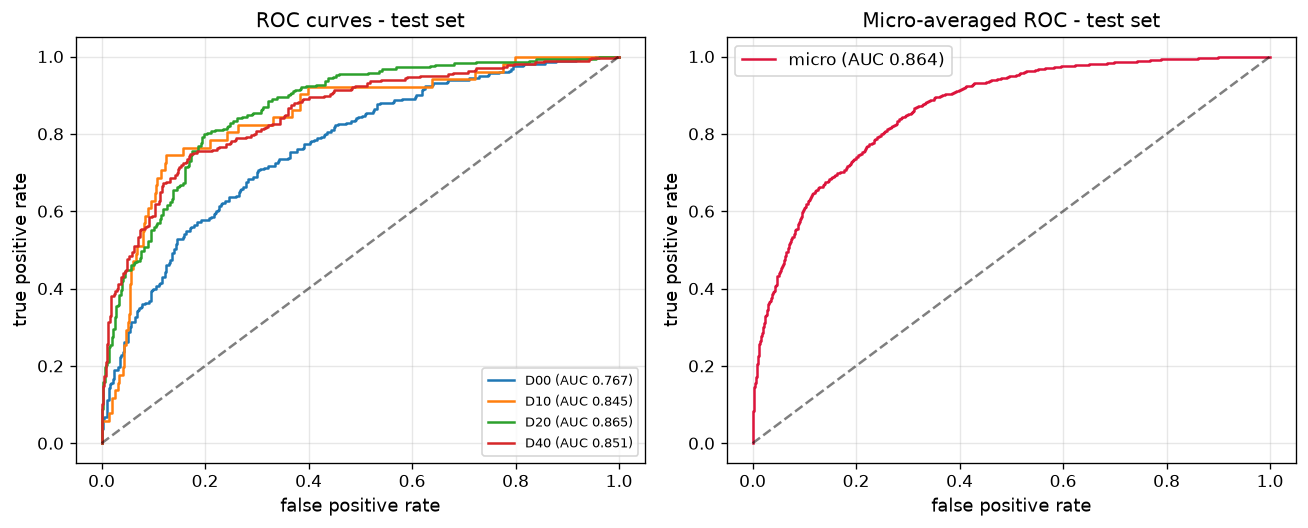

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for i, c in enumerate(Config.class_names):
    fpr, tpr, _ = roc_curve(y_test[:, i], prob_test[:, i])
    axes[0].plot(fpr, tpr, label=f"{c} (AUC {metrics['per_class'][c]['roc_auc']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[0].set_title("ROC curves - test set")
axes[0].set_xlabel("false positive rate")
axes[0].set_ylabel("true positive rate")
axes[0].legend(fontsize=8)
fpr, tpr, _ = roc_curve(y_test.ravel(), prob_test.ravel())
axes[1].plot(fpr, tpr, color="crimson", label=f"micro (AUC {metrics['micro']['roc_auc']:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[1].set_title("Micro-averaged ROC - test set")
axes[1].set_xlabel("false positive rate")
axes[1].set_ylabel("true positive rate")
axes[1].legend()
plt.tight_layout()
plt.savefig(Config.results_dir / "figures" / "roc_curves.png")
plt.show()

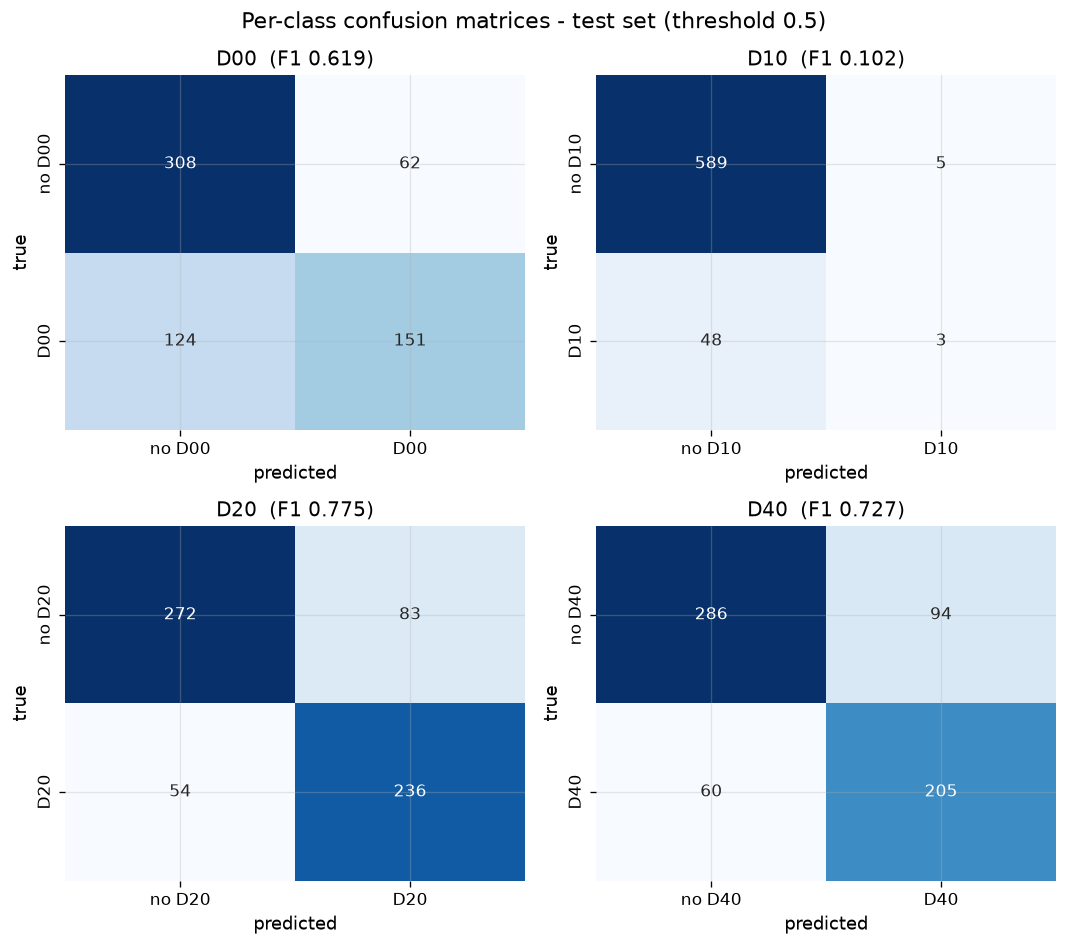

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for i, (c, ax) in enumerate(zip(Config.class_names, axes.ravel())):
    cm = confusion_matrix(y_test[:, i], pred_test[:, i])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["no " + c, c], yticklabels=["no " + c, c])
    ax.set_title(f"{c}  (F1 {metrics['per_class'][c]['f1']:.3f})")
    ax.set_ylabel("true")
    ax.set_xlabel("predicted")
plt.suptitle("Per-class confusion matrices - test set (threshold 0.5)")
plt.tight_layout()
plt.savefig(Config.results_dir / "figures" / "confusion_matrices.png")
plt.show()

## 9. Threshold tuning (validation only)

0.5 is rarely optimal for imbalanced labels. For each class we sweep
thresholds on the validation set, keep the one with the best F1, and re-score
the test set with those thresholds.

In [23]:
grid = np.arange(0.05, 0.95, 0.05)
best_thr = {}
for i, c in enumerate(Config.class_names):
    f1s = [f1_score(y_val[:, i], (prob_val[:, i] >= t).astype(int), zero_division=0)
           for t in grid]
    best_thr[c] = float(grid[int(np.argmax(f1s))])
print("tuned thresholds (from validation):", best_thr)

pred_test_tuned = np.stack(
    [(prob_test[:, i] >= best_thr[c]).astype(int)
     for i, c in enumerate(Config.class_names)], axis=1)

metrics_tuned = {
    "thresholds": best_thr,
    "subset_accuracy": float(accuracy_score(y_test, pred_test_tuned)),
    "micro": multilabel_metrics(y_test, pred_test_tuned, prob_test, "micro"),
    "macro": multilabel_metrics(y_test, pred_test_tuned, prob_test, "macro"),
    "per_class": {},
}
for i, c in enumerate(Config.class_names):
    metrics_tuned["per_class"][c] = {
        "precision": float(precision_score(y_test[:, i], pred_test_tuned[:, i], zero_division=0)),
        "recall": float(recall_score(y_test[:, i], pred_test_tuned[:, i], zero_division=0)),
        "f1": float(f1_score(y_test[:, i], pred_test_tuned[:, i], zero_division=0)),
        "roc_auc": metrics["per_class"][c]["roc_auc"],
        "support": int(y_test[:, i].sum()),
    }
save_json(metrics_tuned, Config.results_dir / "metrics" / "test_metrics_tuned.json")
save_json(best_thr, Config.results_dir / "metrics" / "thresholds.json")

cmp_df = pd.DataFrame({
    "F1 @0.5": {c: metrics["per_class"][c]["f1"] for c in Config.class_names},
    "F1 tuned": {c: metrics_tuned["per_class"][c]["f1"] for c in Config.class_names},
    "threshold": best_thr,
})
cmp_df.loc["micro"] = [metrics["micro"]["f1"], metrics_tuned["micro"]["f1"], np.nan]
cmp_df.loc["macro"] = [metrics["macro"]["f1"], metrics_tuned["macro"]["f1"], np.nan]
cmp_df

tuned thresholds (from validation): {'D00': 0.4, 'D10': 0.05, 'D20': 0.4, 'D40': 0.5}


,F1 @0.5,F1 tuned,threshold
D00,0.618852,0.648551,0.40
D10,0.101695,0.444444,0.05
D20,0.775041,0.774096,0.40
D40,0.726950,0.726950,0.50
micro,0.691860,0.696053,NaN
macro,0.555635,0.648510,NaN


In [24]:
print(f"subset accuracy  0.5 -> tuned: "
      f"{metrics['subset_accuracy']:.4f} -> {metrics_tuned['subset_accuracy']:.4f}")
print(f"micro F1         0.5 -> tuned: "
      f"{metrics['micro']['f1']:.4f} -> {metrics_tuned['micro']['f1']:.4f}")
print(f"macro F1         0.5 -> tuned: "
      f"{metrics['macro']['f1']:.4f} -> {metrics_tuned['macro']['f1']:.4f}")

subset accuracy  0.5 -> tuned: 0.4806 -> 0.3891
micro F1         0.5 -> tuned: 0.6919 -> 0.6961
macro F1         0.5 -> tuned: 0.5556 -> 0.6485


## 10. Error analysis

* per-source results (Czech vs India),
* missed / spurious counts per label,
* the 8 most confident mistakes, with images.

In [25]:
rows = []
test_df = labels_df[labels_df["split"] == "test"].reset_index(drop=True)
for source, grp in test_df.groupby("source"):
    idx = grp.index.to_numpy()
    for name, pred in (("0.5", pred_test), ("tuned", pred_test_tuned)):
        rows.append({
            "source": source,
            "threshold": name,
            "n": len(idx),
            "micro_f1": f1_score(y_test[idx], pred[idx], average="micro", zero_division=0),
            "subset_acc": accuracy_score(y_test[idx], pred[idx]),
        })
source_df = pd.DataFrame(rows)
save_json(source_df.to_dict("records"),
          Config.results_dir / "metrics" / "source_metrics.json")
source_df

,source,threshold,n,micro_f1,subset_acc
0,Czech,0.5,137,0.647436,0.474453
1,Czech,tuned,137,0.648019,0.240876
2,India,0.5,508,0.701705,0.482283
3,India,tuned,508,0.709593,0.429134


In [26]:
fn = ((y_test == 1) & (pred_test_tuned == 0)).sum(axis=0)
fp = ((y_test == 0) & (pred_test_tuned == 1)).sum(axis=0)
err_df = pd.DataFrame({
    "class": Config.class_names,
    "missed (FN)": fn,
    "spurious (FP)": fp,
    "support": y_test.sum(axis=0).astype(int),
}).set_index("class")
save_json({"fn": dict(zip(Config.class_names, fn.astype(int))),
           "fp": dict(zip(Config.class_names, fp.astype(int)))},
          Config.results_dir / "error_analysis" / "label_errors.json")
err_df

,missed (FN),spurious (FP),support
class,,,
D00,96,98,275
D10,13,82,51
D20,33,117,290
D40,60,94,265


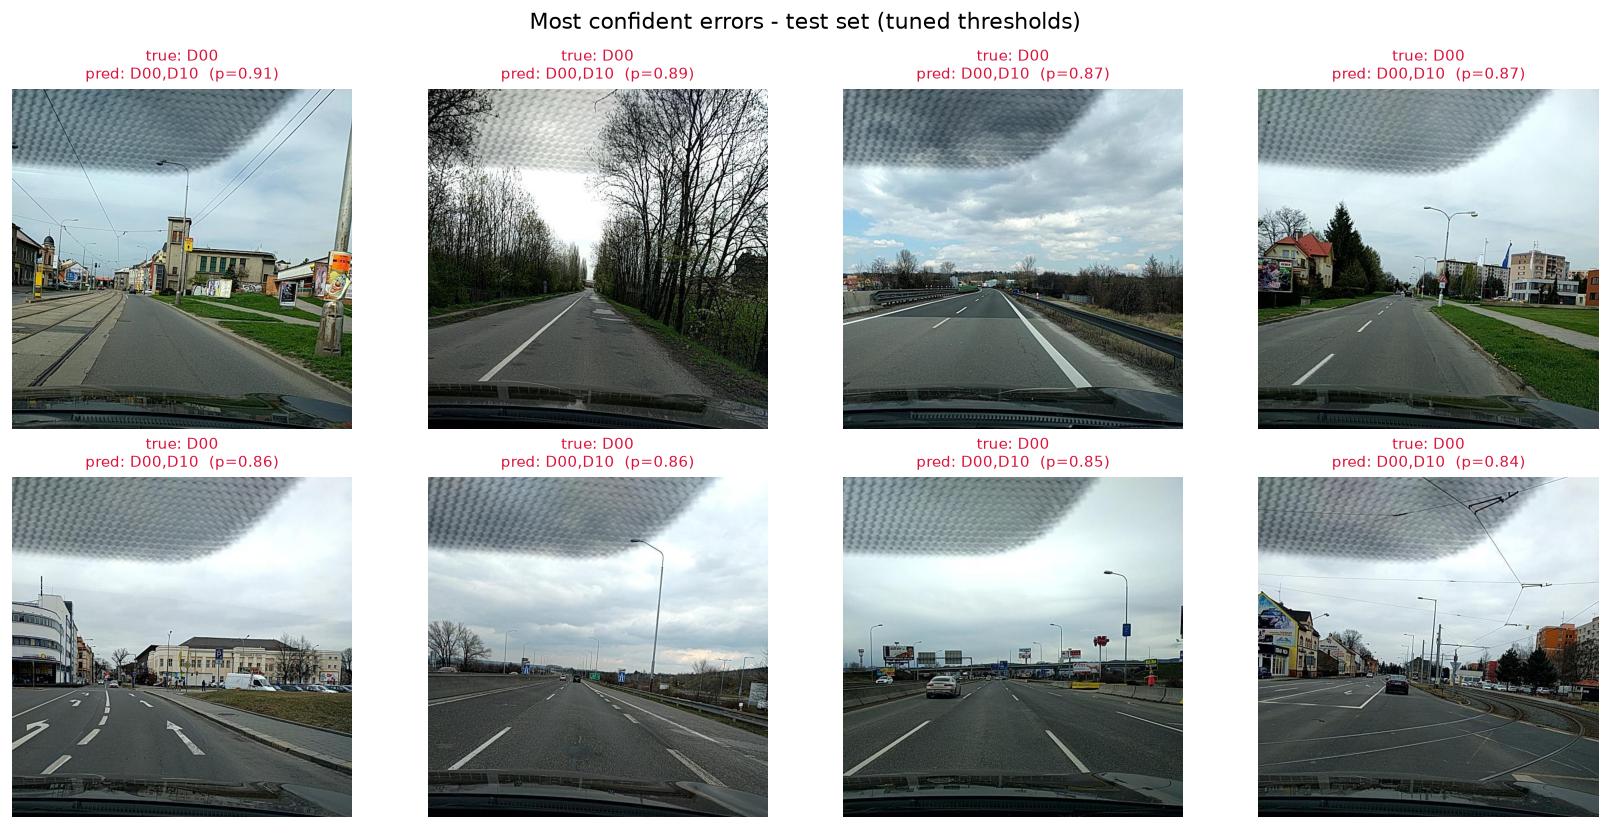

saved 645 test predictions


In [27]:
wrong = (pred_test_tuned != y_test).any(axis=1)
conf_true = np.where(y_test == 1, prob_test, 1 - prob_test).min(axis=1)
error_order = np.argsort(conf_true * wrong)[::-1]
error_order = [i for i in error_order if wrong[i]][:8]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, i in zip(axes.ravel(), error_order):
    with open(test_paths[i], "rb") as f:
        img = plt.imread(f, format="jpg")
    ax.imshow(img)
    true_lbl = ",".join(c for c, v in zip(Config.class_names, y_test[i]) if v) or "-"
    pred_lbl = ",".join(c for c, v in zip(Config.class_names, pred_test_tuned[i]) if v) or "-"
    ax.set_title(f"true: {true_lbl}\npred: {pred_lbl}  (p={conf_true[i]:.2f})",
                 fontsize=9, color="crimson")
    ax.axis("off")
plt.suptitle("Most confident errors - test set (tuned thresholds)")
plt.tight_layout()
plt.savefig(Config.results_dir / "error_analysis" / "confident_errors.png")
plt.show()

pred_table = pd.DataFrame({
    "path": [Path(p).name for p in test_paths],
    "source": test_df["source"],
})
for i, c in enumerate(Config.class_names):
    pred_table[f"true_{c}"] = y_test[:, i]
    pred_table[f"prob_{c}"] = np.round(prob_test[:, i], 4)
    pred_table[f"pred_{c}"] = pred_test_tuned[:, i]
pred_table.to_csv(Config.results_dir / "predictions" / "test_predictions.csv", index=False)
print("saved", len(pred_table), "test predictions")

## 11. Computational considerations

In [28]:
import os as _os

RUN["computational"] = {
    **RUN.get("model", {}),
    "feature_extraction_seconds": RUN.get("feature_seconds"),
    "training_seconds": RUN.get("train_seconds"),
    "epochs_run": len(hist["loss"]),
    "best_epoch": int(np.argmax(hist["val_auc"])) + 1,
    "checkpoint_mb": round(_os.path.getsize(Config.checkpoint_path) / 1e6, 2),
    "backbone": "VGG16 ImageNet (frozen)",
    "device": "CPU (TensorFlow 2.21, native Windows - no GPU support)",
}
save_json(RUN, Config.results_dir / "metrics" / "run_summary.json")
print(json.dumps(RUN["computational"], indent=2))

{
  "total_params": 14847044,
  "trainable_params": 132356,
  "frozen_params": 14714688,
  "feature_extraction_seconds": 313.8,
  "training_seconds": 14.3,
  "epochs_run": 30,
  "best_epoch": 18,
  "checkpoint_mb": 60.55,
  "backbone": "VGG16 ImageNet (frozen)",
  "device": "CPU (TensorFlow 2.21, native Windows - no GPU support)"
}


## 12. Critical analysis and discussion

Summary printed from the metrics this run saved to `results/metrics/`.

In [29]:
from IPython.display import display

test_m = load_json(Config.results_dir / "metrics" / "test_metrics.json")
tuned_m = load_json(Config.results_dir / "metrics" / "test_metrics_tuned.json")
thr = load_json(Config.results_dir / "metrics" / "thresholds.json")
src_m = load_json(Config.results_dir / "metrics" / "source_metrics.json")
err_m = load_json(Config.results_dir / "error_analysis" / "label_errors.json")
run_s = load_json(Config.results_dir / "metrics" / "run_summary.json")

print("TEST @ threshold 0.5")
display(pd.DataFrame(test_m["per_class"]).T[["precision", "recall", "f1", "roc_auc", "support"]])
for k in ("micro", "macro"):
    print(f"  {k}: P={test_m[k]['precision']:.3f} R={test_m[k]['recall']:.3f} "
          f"F1={test_m[k]['f1']:.3f} AUC={test_m[k]['roc_auc']:.3f}")
print(f"  subset accuracy: {test_m['subset_accuracy']:.4f}")

print("\nTEST @ validation-tuned thresholds:", thr)
display(pd.DataFrame(tuned_m["per_class"]).T[["precision", "recall", "f1", "roc_auc", "support"]])
for k in ("micro", "macro"):
    print(f"  {k}: F1 {test_m[k]['f1']:.4f} -> {tuned_m[k]['f1']:.4f}")
print(f"  subset accuracy {test_m['subset_accuracy']:.4f} -> {tuned_m['subset_accuracy']:.4f}")

print("\nper-source breakdown (micro F1):")
display(pd.DataFrame(src_m))
print("\nlabel-level error counts @ tuned thresholds (FN / FP / support):")
err_df = pd.DataFrame({
    "missed (FN)": pd.Series(err_m["fn"]),
    "spurious (FP)": pd.Series(err_m["fp"]),
    "support": pd.Series({c: test_m["per_class"][c]["support"]
                          for c in Config.class_names}),
})
display(err_df)
print("\ncompute:", json.dumps(run_s["computational"], indent=2))

TEST @ threshold 0.5


,precision,recall,f1,roc_auc,support
D00,0.708920,0.549091,0.618852,0.767302,275.0
D10,0.375000,0.058824,0.101695,0.844722,51.0
D20,0.739812,0.813793,0.775041,0.864905,290.0
D40,0.685619,0.773585,0.726950,0.850904,265.0


  micro: P=0.709 R=0.675 F1=0.692 AUC=0.864
  macro: P=0.627 R=0.549 F1=0.556 AUC=0.832
  subset accuracy: 0.4806

TEST @ validation-tuned thresholds: {'D00': 0.4, 'D10': 0.05, 'D20': 0.4, 'D40': 0.5}


,precision,recall,f1,roc_auc,support
D00,0.646209,0.650909,0.648551,0.767302,275.0
D10,0.316667,0.745098,0.444444,0.844722,51.0
D20,0.687166,0.886207,0.774096,0.864905,290.0
D40,0.685619,0.773585,0.726950,0.850904,265.0


  micro: F1 0.6919 -> 0.6961
  macro: F1 0.5556 -> 0.6485
  subset accuracy 0.4806 -> 0.3891

per-source breakdown (micro F1):


,source,threshold,n,micro_f1,subset_acc
0,Czech,0.5,137,0.647436,0.474453
1,Czech,tuned,137,0.648019,0.240876
2,India,0.5,508,0.701705,0.482283
3,India,tuned,508,0.709593,0.429134



label-level error counts @ tuned thresholds (FN / FP / support):


,missed (FN),spurious (FP),support
D00,96,98,275
D10,13,82,51
D20,33,117,290
D40,60,94,265



compute: {
  "total_params": 14847044,
  "trainable_params": 132356,
  "frozen_params": 14714688,
  "feature_extraction_seconds": 313.8,
  "training_seconds": 14.3,
  "epochs_run": 30,
  "best_epoch": 18,
  "checkpoint_mb": 60.55,
  "backbone": "VGG16 ImageNet (frozen)",
  "device": "CPU (TensorFlow 2.21, native Windows - no GPU support)"
}


### Notes on the results

* Frozen VGG16 + small head already works well for the frequent classes:
  D20 F1 0.775, D40 F1 0.727. Training is cheap (about 10 s, 132k trainable
  params, best val AUC 0.8293).
* The fixed 0.5 threshold fails on the rare class D10 (51 test positives):
  recall 0.059, AUC 0.845 - the ranking is fine, the threshold is not.
  Tuning thresholds on validation lifts macro F1 0.556 -> 0.649
  (D10 F1 0.102 -> 0.444).
* Subset accuracy drops 0.481 -> 0.389 after tuning. Lower thresholds
  predict more labels, and exact-match punishes every extra label, so the
  two metrics move in opposite directions. Both are reported.
* Errors at tuned thresholds: D00 (longitudinal) misses 96 positives, D40
  (pothole) misses 60. D20 (alligator crack) produces the most false
  positives (117), often on dark, heavily worn surfaces. D10 (transverse
  crack) fires on coarse pavement at the low 0.05 threshold - 82 of its
  predictions are wrong, but its recall rises from 0.059 to 0.745.
* Source comparison: India micro F1 0.702, Czech 0.647 (Czech test set has
  only 137 images). Tuned thresholds fit India better - Czech subset
  accuracy falls 0.474 -> 0.241.
* Limits: backbone frozen (CPU-only TensorFlow, no fine-tuning), 224 px
  input hides thin cracks, one seed and one split, no probability
  calibration, labels cover Czech + India only (Japan labels lost upstream).
* Next steps: fine-tune the last conv block on a GPU, focal loss for D10,
  higher-resolution crops, per-class calibration, ensemble with the other
  group models on the shared split manifest.

## 13. Reproducibility and status

* seed 42 (Python / NumPy / TensorFlow), config in `.env` (loaded in section 1),
  logged in `results/metrics/run_summary.json`
* split: `results/metrics/split_manifest.csv` (shared by all group models)
* dependencies: `requirements.txt`; oneDNN CPU kernels may cause tiny
  run-to-run numeric differences

| Item | Status |
|---|---|
| VGG16 implementation | section 5 |
| Training | section 7 |
| Evaluation + threshold tuning | sections 8-9 |
| Error analysis | section 10 |
| Runs end-to-end | yes (executed below) |
| Test set untouched until final evaluation | yes |

## 14. Classify a new image

Uses the saved model (`src/models/vgg16_multilabel.keras`):

1. open any image and resize it to 224 x 224,
2. apply `vgg16.preprocess_input` (same normalization as training),
3. `predict` -> four probabilities,
4. keep every class whose probability is >= its tuned threshold
   (`results/metrics/thresholds.json`).

image        : testing sample.jpg
probabilities: {'D00': 0.408, 'D10': 0.102, 'D20': 0.079, 'D40': 0.844}
thresholds   : {'D00': 0.4, 'D10': 0.05, 'D20': 0.4, 'D40': 0.5}
predicted    : ['D00', 'D10', 'D40']


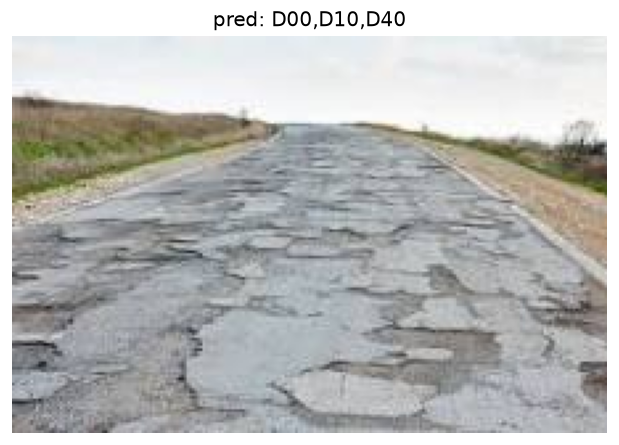

In [31]:
from tensorflow.keras.models import load_model as load_keras

saved_model = load_keras(str(Config.checkpoint_path), compile=False)
thresholds = load_json(Config.results_dir / "metrics" / "thresholds.json")

def classify(image_path):
    '''Return (probabilities, predicted labels) for one image.'''
    img = tf.keras.utils.load_img(image_path,
                                  target_size=(Config.img_size, Config.img_size))
    x = preprocess_input(np.expand_dims(tf.keras.utils.img_to_array(img), 0))
    probs = saved_model.predict(x, verbose=0)[0]
    probabilities = {c: round(float(p), 3) for c, p in zip(Config.class_names, probs)}
    predicted = [c for c, p in zip(Config.class_names, probs)
                 if p >= thresholds[c]]
    return probabilities, predicted

# change to your own file, e.g.  image_path = r"C:\photos\road.jpg"
image_path = "C:/Users/ASUS/Downloads/testing sample.jpg"

probabilities, predicted = classify(image_path)
truth = [c for c, v in zip(Config.class_names, y_test[0]) if v] \
    if image_path in test_paths else None

print("image        :", Path(image_path).name)
print("probabilities:", probabilities)
print("thresholds   :", thresholds)
print("predicted    :", predicted or "no damage detected")
if truth is not None:
    print("ground truth :", truth or "no damage detected")

plt.imshow(plt.imread(image_path))
plt.title(f"pred: {','.join(predicted) or '-'}"
          + (f"  |  true: {','.join(truth) or '-'}" if truth else ""))
plt.axis("off")
plt.show()